# Разведочный анализ данных (EDA)
Датасет: Default of Credit Card Clients


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('../data/UCI_Credit_Card.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Информация о датасете

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [17]:
# Проверка пропущенных значений
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() >0 else 'Пропусков нет')

Пропусков нет


In [6]:
# Статистика числовых признаков
df.describe().round(2)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


### Анализ целевой переменной

Распределение классов:
Нет дефолта (0):23364 клиентов (77.9%)
Дефолт (1): 6636 клиентов (22.1%)


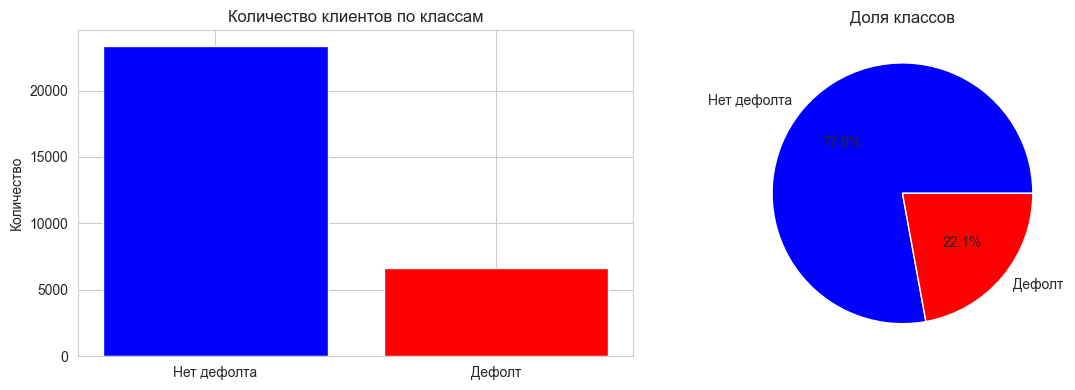

In [18]:
target = df['default.payment.next.month']
counts = target.value_counts()

print('Распределение классов:')
print(f'Нет дефолта (0):{counts[0]} клиентов ({counts[0]/len(df)*100:.1f}%)')
print(f'Дефолт (1): {counts[1]} клиентов ({counts[1]/len(df)*100:.1f}%)')

# график
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Нет дефолта', 'Дефолт'], counts.values, color=['blue', 'red'])
axes[0].set_title('Количество клиентов по классам')
axes[0].set_ylabel('Количество')

axes[1].pie(counts.values, labels=['Нет дефолта', 'Дефолт'], autopct='%1.1f%%', colors=['blue', 'red'])
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.show()

**Вывод:** Классы несбалансированы - дефолтников примерно в 3.5 раза меньше
При обучении модели используем `class_weight='balanced'` чтобы компенсировать этот дисбаланс.

### Демографические признаки

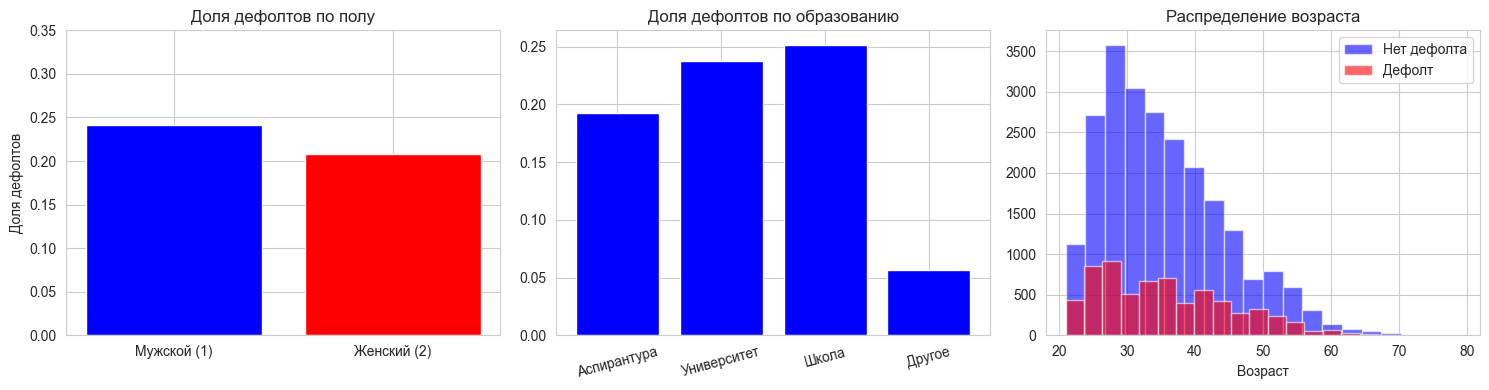

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Пол
sex_default = df.groupby('SEX')['default.payment.next.month'].mean()
axes[0].bar(['Мужской (1)','Женский (2)'], sex_default.values, color=['blue', 'red'])
axes[0].set_title('Доля дефолтов по полу')
axes[0].set_ylabel('Доля дефолтов')
axes[0].set_ylim(0, 0.35)

# Образование
edu_labels = {1:'Аспирантура', 2: 'Университет', 3:'Школа', 4: 'Другое'}
edu_data = df[df['EDUCATION'].isin([1,2,3,4])]
edu_default = edu_data.groupby('EDUCATION')['default.payment.next.month'].mean()
axes[1].bar([edu_labels[i] for i in edu_default.index], edu_default.values, color='blue')
axes[1].set_title('Доля дефолтов по образованию')
axes[1].tick_params(axis='x', rotation=15)

# Возраст
axes[2].hist(df[df['default.payment.next.month']==0]['AGE'],bins=20,alpha=0.6,label='Нет дефолта', color='blue')
axes[2].hist(df[df['default.payment.next.month']==1]['AGE'],bins=20,alpha=0.6, label='Дефолт', color='red')
axes[2].set_title('Распределение возраста')
axes[2].set_xlabel('Возраст')
axes[2].legend()

plt.tight_layout()
plt.show()

### Кредитный лимит и дефолт

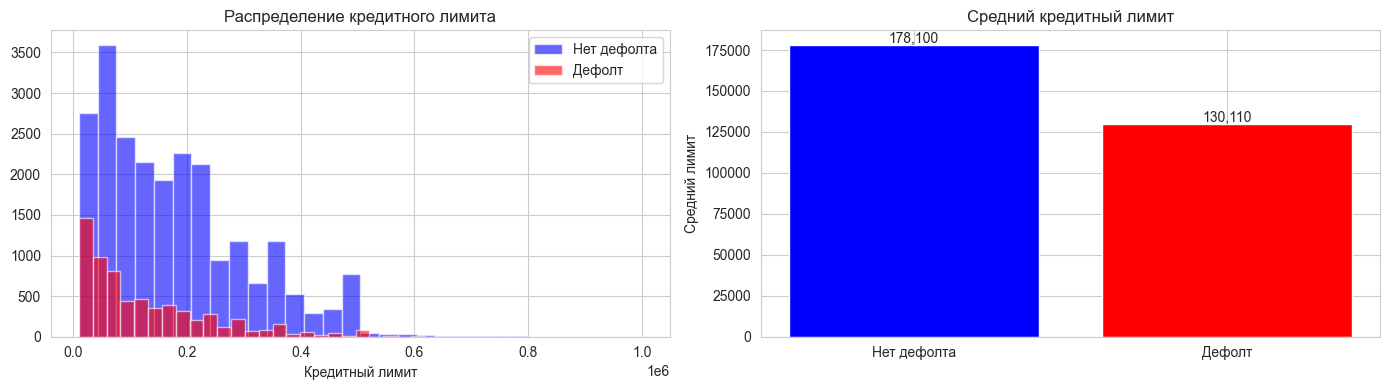

Средний лимит у надёжных клиентов: 178,100
Средний лимит у дефолтников:130,110


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Распределение лимита по классам
df[df['default.payment.next.month']==0]['LIMIT_BAL'].hist(bins=30, ax=axes[0], alpha=0.6, label='Нет дефолта', color='blue')
df[df['default.payment.next.month']==1]['LIMIT_BAL'].hist(bins=30, ax=axes[0], alpha=0.6, label='Дефолт', color='red')
axes[0].set_title('Распределение кредитного лимита')
axes[0].set_xlabel('Кредитный лимит')
axes[0].legend()

# Средний лимит по классам
avg_limit = df.groupby('default.payment.next.month')['LIMIT_BAL'].mean()
axes[1].bar(['Нет дефолта', 'Дефолт'], avg_limit.values, color=['blue', 'red'])
axes[1].set_title('Средний кредитный лимит')
axes[1].set_ylabel('Средний лимит')
for i, v in enumerate(avg_limit.values):
    axes[1].text(i, v + 1000, f'{v:,.0f}', ha='center')

plt.tight_layout()
plt.show()

print(f'Средний лимит у надёжных клиентов: {avg_limit[0]:,.0f}')
print(f'Средний лимит у дефолтников:{avg_limit[1]:,.0f}')

### История платежей (PAY_0...PAY_6)

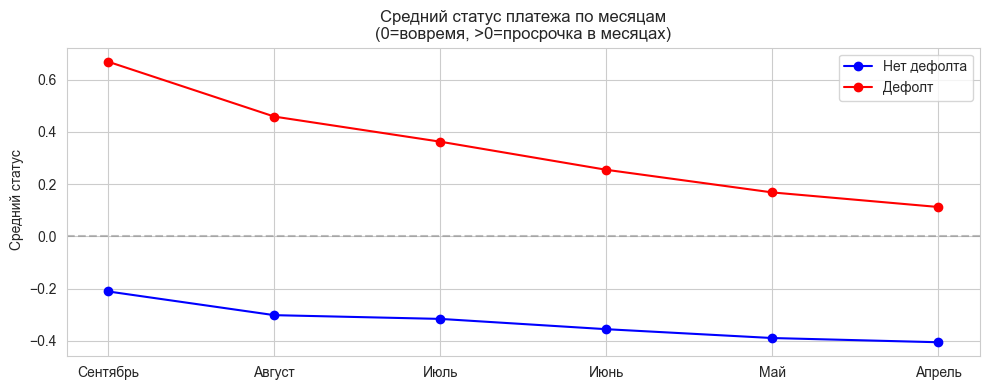

In [21]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
months = ['Сентябрь', 'Август', 'Июль', 'Июнь', 'Май', 'Апрель']

# Средний статус платежа по классам
avg_pay_no_default = df[df['default.payment.next.month']==0][pay_cols].mean()
avg_pay_default = df[df['default.payment.next.month']==1][pay_cols].mean()

x = range(len(pay_cols))
plt.figure(figsize=(10, 4))
plt.plot(x, avg_pay_no_default.values,'o-', label='Нет дефолта', color='blue')
plt.plot(x, avg_pay_default.values,'o-', label='Дефолт',color='red')
plt.xticks(list(x), months)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Средний статус платежа по месяцам\n(0=вовремя, >0=просрочка в месяцах)')
plt.ylabel(' Средний статус')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** У дефолтников статус платежей значительно хуже, в среднем они просрочивают платежи,  
тогда как надёжные клиенты платят вовремя. Это самый важный признак для модели

### Корреляция признаков с целевой переменной

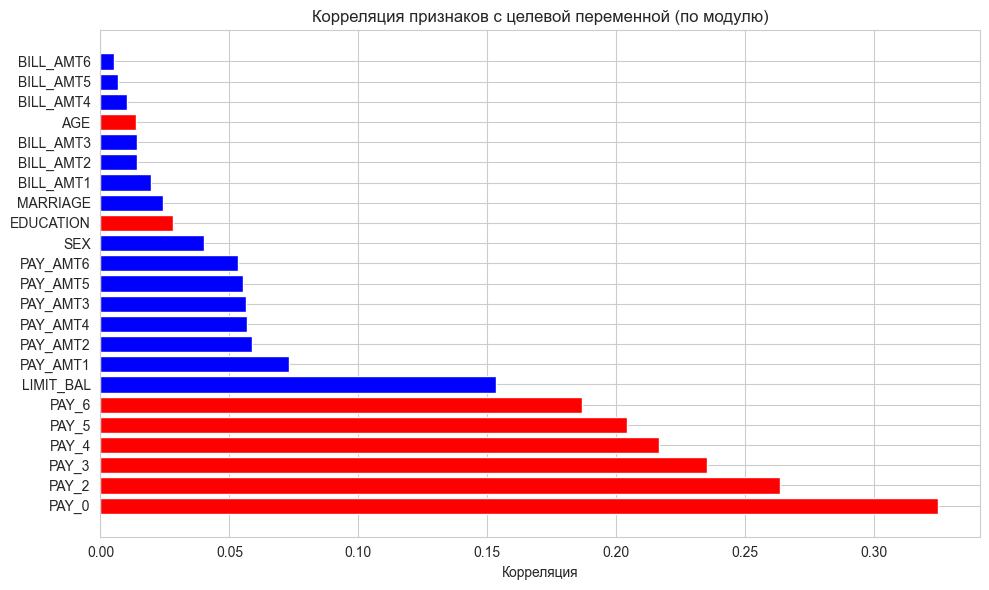

5 самых важных признаков:
  PAY_0: 0.325
  PAY_2: 0.264
  PAY_3: 0.235
  PAY_4: 0.217
  PAY_5: 0.204


In [23]:
# Убираем ID, считаем корреляцию с таргетом
corr = df.drop(columns=['ID']).corr()['default.payment.next.month'].drop('default.payment.next.month')
corr_sorted = corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if corr[f] > 0 else 'blue' for f in corr_sorted.index]
plt.barh(corr_sorted.index, corr_sorted.values, color=colors)
plt.title('Корреляция признаков с целевой переменной (по модулю)')
plt.xlabel('Корреляция')
plt.tight_layout()
plt.show()

print('5 самых важных признаков:')
for feat, val in corr_sorted.head(5).items():
    print(f'  {feat}: {val:.3f}')

### Итоги EDA

| Наблюдение | Вывод для модели |
|---|---|
| Дисбаланс классов 78/22 | Использовать `class_weight='balanced'` |
| PAY_0 | История платежей важнее демографии |
| Дефолтники имеют меньший лимит | LIMIT_BAL полезный признак |
| Пропусков нет | Предобработка минимальна |
| Все признаки числовые | Не нужна кодировка категорий |